In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split


%matplotlib inline

### 1-Dataset

In [6]:
dataset = pd.read_csv("mouse_viral_study.csv")
dataset

,Med_1_mL,Med_2_mL,Virus Present
0,6.508231,8.582531,0
1,4.126116,3.073459,1
2,6.427870,6.369758,0
3,3.672953,4.905215,1
4,1.580321,2.440562,1
...,...,...,...
395,2.884122,3.271748,1
396,7.290855,9.488672,0
397,7.895325,8.272529,0
398,2.690592,2.674979,1


In [7]:
X = dataset[['Med_1_mL', 'Med_2_mL']].values
y = dataset[['Virus Present']].values

In [8]:
X.shape, y.shape

((400, 2), (400, 1))

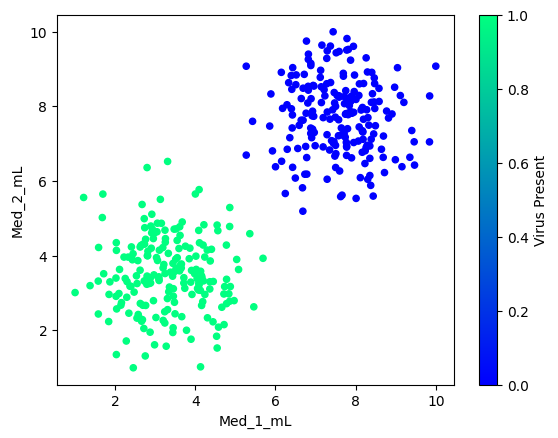

In [9]:
dataset.plot.scatter(x='Med_1_mL',y='Med_2_mL', c='Virus Present', colormap='winter')
plt.show()

### 2- Le split

In [10]:
# découpage du dataset en dataset d'entrainement et dataset de test
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(320, 2)
(80, 2)
(320, 1)
(80, 1)


### 3- Modele

In [11]:
# La fonction sigmoide
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [12]:
def initialisation(X):
    W = np.random.randn(X.shape[1], 1)
    b = np.random.randn(1)
    return (W, b)

In [13]:
# Modèle
def modele(X, W, b):
    Z = X.dot(W) + b
    A = sigmoid(Z)
    return A

### 4- Fonction cout

In [16]:
def log_loss(y, A):
    return 1/len(y) * np.sum(-y * np.log(A) - (1 - y) * np.log(1 - A))

### 5- Optimisation (Entrainement) - Gradient et Descente de gradient

In [17]:
def gradients(X, A, y):
    dW = 1/len(y) * np.dot(X.T, A - y)
    db = 1/len(y) * np.sum(A - y)
    return (dW, db)

In [18]:
def optimisation(X, W, b, A, y, learning_rate):
    dW, db = gradients(X, A, y)
    W = W - learning_rate * dW
    b = b - learning_rate * db
    return (W, b)

In [25]:
#Initialisation
W, b = initialisation(X)

#Entrainement
learning_rate=0.1
n_iter=1000
loss_history = []
for i in range(n_iter):
    A = modele(x_train, W, b)
    loss_history.append(log_loss(y_train, A))
    W, b = optimisation(x_train, W, b, A, y_train, learning_rate=0.1)

### 6- Courbe d'apprentissage

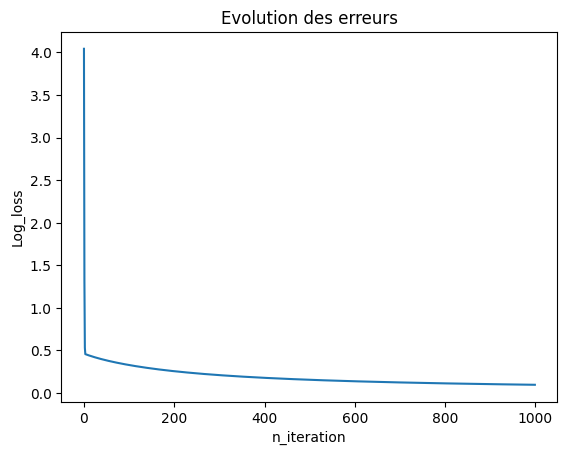

In [26]:
plt.plot(loss_history)
plt.xlabel('n_iteration')
plt.ylabel('Log_loss')
plt.title('Evolution des erreurs')
plt.show()


### 7- Prediction

In [28]:
def predict(X, W, b):
    A = modele(X, W, b)
    print(A)
    return A >= 0.5

### 8-  Evaluation du modele et visualisation

In [29]:
from sklearn.metrics import accuracy_score
y_pred = predict(x_test, W, b)
print("Accuracy=",accuracy_score(y_test, y_pred))

[[0.07179798]
 [0.91555626]
 [0.05943132]
 [0.01749481]
 [0.82642141]
 [0.01734553]
 [0.0984842 ]
 [0.87961681]
 [0.88523474]
 [0.03570708]
 [0.86743181]
 [0.88488818]
 [0.03917451]
 [0.03711185]
 [0.91918252]
 [0.77996842]
 [0.76580019]
 [0.04626703]
 [0.69232388]
 [0.06050392]
 [0.94604548]
 [0.02147904]
 [0.0257993 ]
 [0.08952554]
 [0.06285326]
 [0.02308497]
 [0.01371182]
 [0.95220342]
 [0.08622396]
 [0.05287201]
 [0.93787074]
 [0.55502407]
 [0.9373937 ]
 [0.02758404]
 [0.05258   ]
 [0.03742909]
 [0.62793164]
 [0.89929332]
 [0.10045434]
 [0.07360852]
 [0.85785168]
 [0.03092928]
 [0.91370404]
 [0.05820379]
 [0.02366436]
 [0.90466312]
 [0.10707551]
 [0.96819998]
 [0.01167678]
 [0.02043023]
 [0.88031228]
 [0.79739428]
 [0.02814649]
 [0.93377558]
 [0.07148007]
 [0.9269005 ]
 [0.04930605]
 [0.89176738]
 [0.03420501]
 [0.95704722]
 [0.8536169 ]
 [0.91883145]
 [0.95102543]
 [0.94182334]
 [0.04162467]
 [0.01548131]
 [0.92780538]
 [0.77337398]
 [0.71794379]
 [0.95908584]
 [0.05051018]
 [0.07

C:\Users\4B\AppData\Local\Temp\ipykernel_20060\1234893373.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  b_val = float(b)


[[0.98241959]
 [0.1738958 ]
 [0.87228258]]


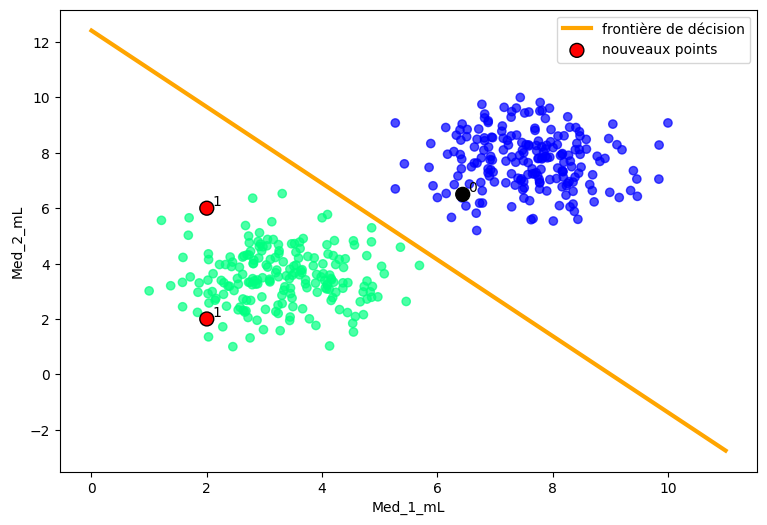

In [32]:
# Visualiser le dataset
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X[:,0], X[:, 1], c=y.ravel(), cmap='winter', alpha=0.7)

# Préparer W et b comme scalaires/vecteurs 1D
W_vec = W.ravel()
b_val = float(b)

# Dessiner la frontière de décision sur l'étendue réelle des données
x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
x1 = np.linspace(x_min, x_max, 200)
# éviter division par zéro si W[1] proche de 0
if abs(W_vec[1]) < 1e-8:
    x2 = np.full_like(x1, -b_val / (W_vec[0] + 1e-8))
else:
    x2 = (-W_vec[0] * x1 - b_val) / W_vec[1]
ax.plot(x1, x2, c='orange', lw=3, label='frontière de décision')

# Prédire la classe de nouveaux éléments (passer en 2D)
news = np.array([[2.0, 2.0],
                 [6.44, 6.5],
                 [2.0, 6.0]])
preds = predict(news, W, b)  # predict accepte maintenant (n,2)

# Afficher les nouveaux points colorés selon la prédiction
colors = ['red' if p else 'black' for p in preds.ravel()]
ax.scatter(news[:,0], news[:,1], c=colors, s=100, edgecolor='k', label='nouveaux points')

# Annoter les prédictions
for pt, p in zip(news, preds.ravel()):
    ax.annotate(str(int(p)), (pt[0]+0.1, pt[1]+0.1))

ax.set_xlabel('Med_1_mL')
ax.set_ylabel('Med_2_mL')
ax.legend()
plt.show()

In [33]:
#Matrice de confusion
from sklearn.metrics import confusion_matrix
y_pred = predict(x_test, W, b)
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[0.07179798]
 [0.91555626]
 [0.05943132]
 [0.01749481]
 [0.82642141]
 [0.01734553]
 [0.0984842 ]
 [0.87961681]
 [0.88523474]
 [0.03570708]
 [0.86743181]
 [0.88488818]
 [0.03917451]
 [0.03711185]
 [0.91918252]
 [0.77996842]
 [0.76580019]
 [0.04626703]
 [0.69232388]
 [0.06050392]
 [0.94604548]
 [0.02147904]
 [0.0257993 ]
 [0.08952554]
 [0.06285326]
 [0.02308497]
 [0.01371182]
 [0.95220342]
 [0.08622396]
 [0.05287201]
 [0.93787074]
 [0.55502407]
 [0.9373937 ]
 [0.02758404]
 [0.05258   ]
 [0.03742909]
 [0.62793164]
 [0.89929332]
 [0.10045434]
 [0.07360852]
 [0.85785168]
 [0.03092928]
 [0.91370404]
 [0.05820379]
 [0.02366436]
 [0.90466312]
 [0.10707551]
 [0.96819998]
 [0.01167678]
 [0.02043023]
 [0.88031228]
 [0.79739428]
 [0.02814649]
 [0.93377558]
 [0.07148007]
 [0.9269005 ]
 [0.04930605]
 [0.89176738]
 [0.03420501]
 [0.95704722]
 [0.8536169 ]
 [0.91883145]
 [0.95102543]
 [0.94182334]
 [0.04162467]
 [0.01548131]
 [0.92780538]
 [0.77337398]
 [0.71794379]
 [0.95908584]
 [0.05051018]
 [0.07

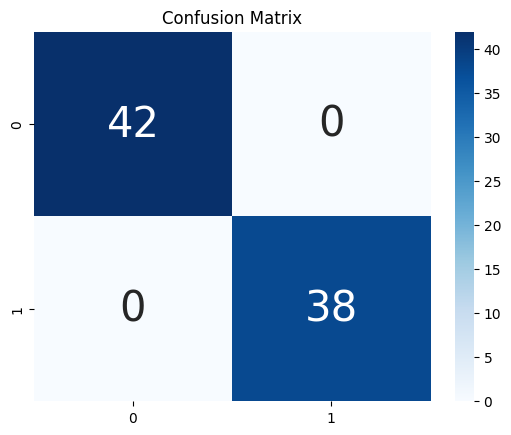

In [34]:
# Plot confusion matrix
import seaborn as sns
import pandas as pd
# confusion matrix sns heatmap 
## https://www.kaggle.com/agungor2/various-confusion-matrix-plots
ax = plt.axes()
df_cm = cm
sns.heatmap(df_cm, annot=True, annot_kws={"size": 30}, fmt='d',cmap="Blues", ax = ax )
ax.set_title('Confusion Matrix')
plt.show()

Le modèle a parfaitement appris la relation entre les features et la target.

## Frontiere de decision en tant que plan 

Shape de X: (200, 3)
Shape de y: (200, 1)
Distribution des classes: (array([0, 1]), array([ 98, 102]))


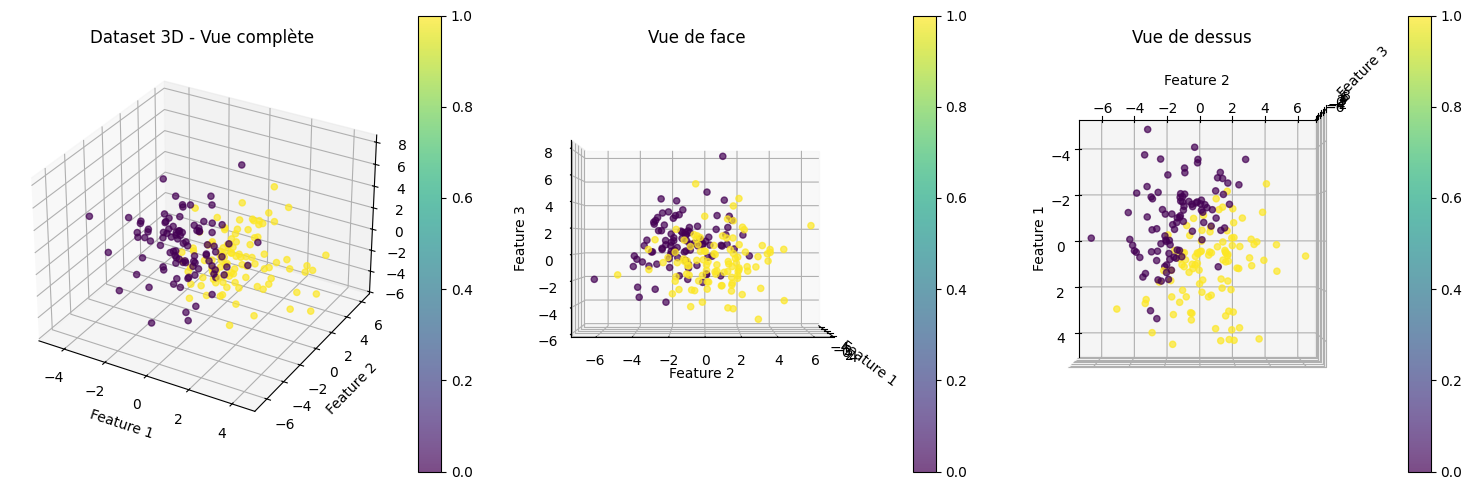

Train shape: (160, 3), Test shape: (40, 3)
y_train shape: (160, 1), y_test shape: (40, 1)


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split

# Génération d'un dataset 3D linéairement séparable
np.random.seed(42)
n_samples = 200

# Générer des points 3D aléatoires
X = np.random.randn(n_samples, 3) * 2

# Définir un plan séparateur : 2*x1 + 1.5*x2 - 1*x3 + 0.5 = 0
W_true = np.array([2, 1.5, -1])
b_true = 0.5

# Calculer la classe basée sur la position par rapport au plan
y = (X.dot(W_true) + b_true > 0).astype(int)

# CORRECTION : Reshape y pour avoir la forme (200, 1) au lieu de (200,)
y = y.reshape(-1, 1)

# Afficher les statistiques du dataset
print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"Distribution des classes: {np.unique(y, return_counts=True)}")

# Visualisation 3D du dataset
fig = plt.figure(figsize=(15, 5))

# Subplot 1: Vue 3D
ax1 = fig.add_subplot(131, projection='3d')
scatter = ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=y.ravel(), cmap='viridis', alpha=0.7)
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_zlabel('Feature 3')
ax1.set_title('Dataset 3D - Vue complète')
plt.colorbar(scatter, ax=ax1)

# Subplot 2: Vue de face
ax2 = fig.add_subplot(132, projection='3d')
scatter = ax2.scatter(X[:, 0], X[:, 1], X[:, 2], c=y.ravel(), cmap='viridis', alpha=0.7)
ax2.view_init(elev=0, azim=0)  # Vue de face
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.set_zlabel('Feature 3')
ax2.set_title('Vue de face')
plt.colorbar(scatter, ax=ax2)

# Subplot 3: Vue de dessus
ax3 = fig.add_subplot(133, projection='3d')
scatter = ax3.scatter(X[:, 0], X[:, 1], X[:, 2], c=y.ravel(), cmap='viridis', alpha=0.7)
ax3.view_init(elev=90, azim=0)  # Vue de dessus
ax3.set_xlabel('Feature 1')
ax3.set_ylabel('Feature 2')
ax3.set_zlabel('Feature 3')
ax3.set_title('Vue de dessus')
plt.colorbar(scatter, ax=ax3)

plt.tight_layout()
plt.show()

# Split des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

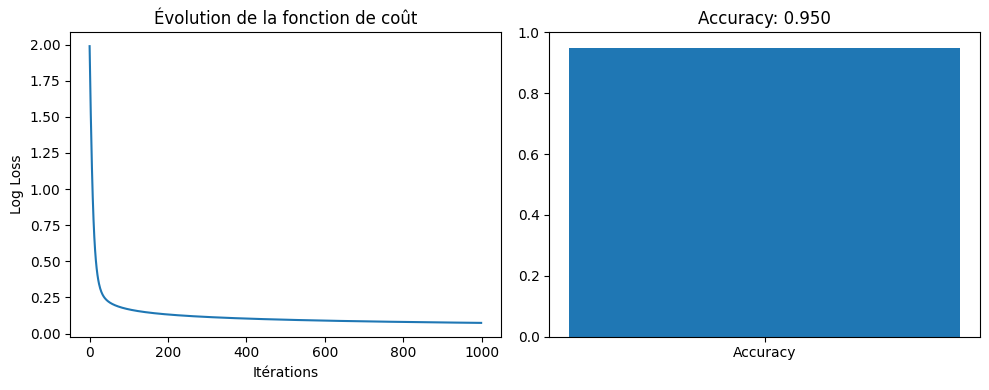

Accuracy finale: 0.950


In [38]:
# Réutiliser vos fonctions avec adaptation pour la 3D
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def initialisation(X):
    W = np.random.randn(X.shape[1], 1)
    b = np.random.randn(1)
    return (W, b)

def modele(X, W, b):
    Z = X.dot(W) + b
    A = sigmoid(Z)
    return A

def log_loss(y, A):
    epsilon = 1e-15  # Pour éviter log(0)
    A = np.clip(A, epsilon, 1 - epsilon)
    return 1/len(y) * np.sum(-y * np.log(A) - (1 - y) * np.log(1 - A))

def gradients(X, A, y):
    dW = 1/len(y) * np.dot(X.T, A - y)
    db = 1/len(y) * np.sum(A - y)
    return (dW, db)

def optimisation(X, W, b, A, y, learning_rate):
    dW, db = gradients(X, A, y)
    W = W - learning_rate * dW
    b = b - learning_rate * db
    return (W, b)

def predict(X, W, b):
    A = modele(X, W, b)
    return A >= 0.5

# Entraînement du modèle
W, b = initialisation(X_train)
learning_rate = 0.1
n_iter = 1000
loss_history = []

for i in range(n_iter):
    A = modele(X_train, W, b)
    loss_history.append(log_loss(y_train, A))
    W, b = optimisation(X_train, W, b, A, y_train, learning_rate)

# Courbe de loss
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.xlabel('Itérations')
plt.ylabel('Log Loss')
plt.title('Évolution de la fonction de coût')

# Évaluation
y_pred = predict(X_test, W, b)
accuracy = np.mean(y_pred == y_test)
plt.subplot(1, 2, 2)
plt.bar(['Accuracy'], [accuracy])
plt.ylim(0, 1)
plt.title(f'Accuracy: {accuracy:.3f}')
plt.tight_layout()
plt.show()

print(f"Accuracy finale: {accuracy:.3f}")

C:\Users\4B\AppData\Local\Temp\ipykernel_20060\4151289899.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  b_val = float(b)



Vues du plan de décision:


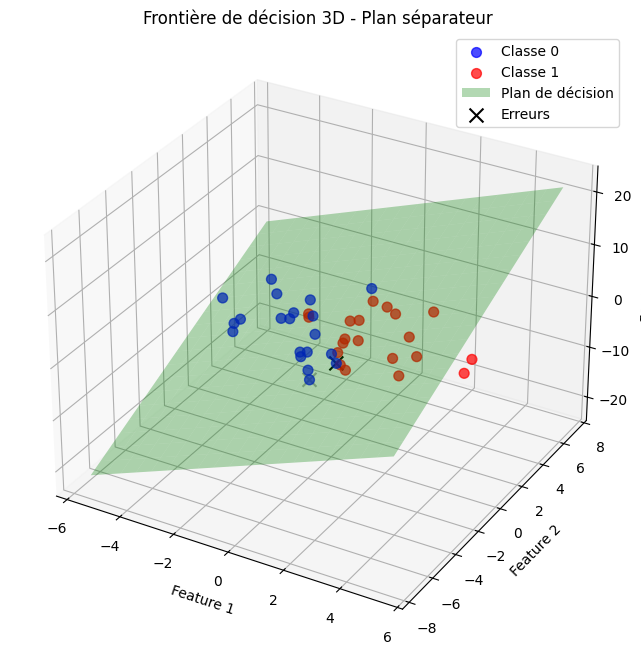

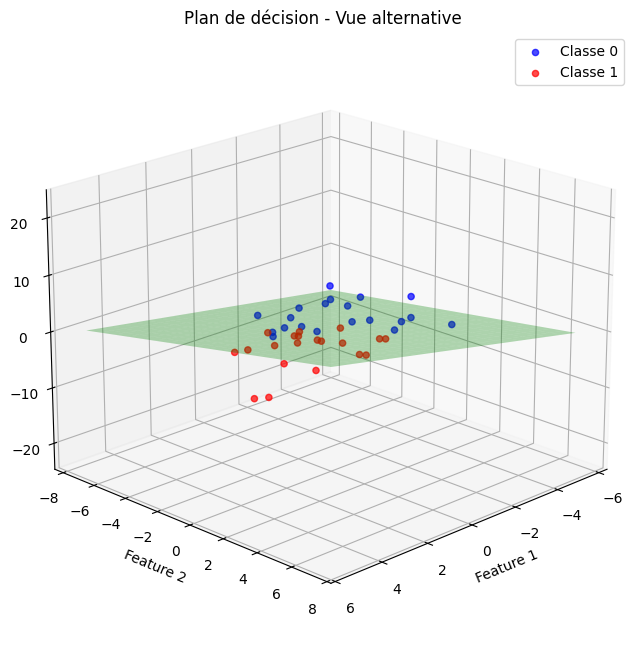


Comparaison des plans:
Plan théorique:    2.000*x1 + 1.500*x2 + -1.000*x3 + 0.500 = 0
Plan appris:       3.445*x1 + 2.536*x2 + -1.732*x3 + 0.908 = 0


In [40]:
# Visualisation 3D avec le plan de décision
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# CORRECTION : utiliser y_test.ravel() pour les indexations
ax.scatter(X_test[y_test.ravel()==0, 0], X_test[y_test.ravel()==0, 1], X_test[y_test.ravel()==0, 2], 
           c='blue', label='Classe 0', alpha=0.7, s=50)
ax.scatter(X_test[y_test.ravel()==1, 0], X_test[y_test.ravel()==1, 1], X_test[y_test.ravel()==1, 2], 
           c='red', label='Classe 1', alpha=0.7, s=50)

# Créer le plan de décision
xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 20),
                     np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 20))

# Équation du plan : W0*x + W1*y + W2*z + b = 0 → z = (-W0*x - W1*y - b)/W2
W_vec = W.ravel()
b_val = float(b)

# Éviter division par zéro
if abs(W_vec[2]) > 1e-8:
    zz = (-W_vec[0] * xx - W_vec[1] * yy - b_val) / W_vec[2]
else:
    zz = np.zeros_like(xx)

# Afficher le plan
ax.plot_surface(xx, yy, zz, alpha=0.3, color='green', label='Plan de décision')

# Marquer les mauvaises prédictions (CORRECTION ici aussi)
y_pred_flat = y_pred.ravel()
y_test_flat = y_test.ravel()
incorrect = (y_pred_flat != y_test_flat)
if np.any(incorrect):
    ax.scatter(X_test[incorrect, 0], X_test[incorrect, 1], X_test[incorrect, 2], 
               c='black', marker='x', s=100, label='Erreurs')

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
ax.set_title('Frontière de décision 3D - Plan séparateur')
ax.legend()

# Plusieurs vues pour mieux voir
print("\nVues du plan de décision:")
plt.show()

# Vue supplémentaire avec un angle différent
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# CORRECTION : utiliser y_test.ravel() ici aussi
ax.scatter(X_test[y_test.ravel()==0, 0], X_test[y_test.ravel()==0, 1], X_test[y_test.ravel()==0, 2], 
           c='blue', label='Classe 0', alpha=0.7)
ax.scatter(X_test[y_test.ravel()==1, 0], X_test[y_test.ravel()==1, 1], X_test[y_test.ravel()==1, 2], 
           c='red', label='Classe 1', alpha=0.7)
ax.plot_surface(xx, yy, zz, alpha=0.3, color='green')

ax.view_init(elev=20, azim=45)  # Angle de vue différent
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
ax.set_title('Plan de décision - Vue alternative')
ax.legend()
plt.show()

# Comparaison avec le plan théorique
print(f"\nComparaison des plans:")
print(f"Plan théorique:    {W_true[0]:.3f}*x1 + {W_true[1]:.3f}*x2 + {W_true[2]:.3f}*x3 + {b_true:.3f} = 0")
print(f"Plan appris:       {W_vec[0]:.3f}*x1 + {W_vec[1]:.3f}*x2 + {W_vec[2]:.3f}*x3 + {b_val:.3f} = 0")